### ♟️ Chess Performance Analysis Using Engine Evaluation

**Overview:** 
This project analyzes my personal chess games (extracted from Chess.com) using Python and the Stockfish 14.1 chess engine to identify specific patterns in my decision-making. The goal is to move beyond surface-level win/loss statistics and programmatically evaluate the quality of individual moves across different phases of the game.

**What This Notebook Does:**
1. **Data Extraction:** Parses raw PGN files containing my historical match data into structured Pandas DataFrames.
2. **Engine Evaluation:** Leverages `python-chess` and the Stockfish UCI engine to analyze board positions before and after each move.
3. **Algorithmic Scoring:** Calculates the exact centipawn evaluation change for every move, actively filtering out engine horizon noise.
4. **Phase Classification:** Segments games into Opening, Middlegame, and Endgame phases, automatically classifying moves from "Brilliant" to "Blunder."
5. **Trend Visualization:** Visualizes performance trends over time using `matplotlib`.

**Environment Note:** *This notebook was developed and executed in a hosted Kaggle environment. File paths (e.g., `/kaggle/input/...`) and OS-level engine installations (like `apt-get`) are specific to Kaggle's Linux backend. To execute this code interactively, please view the hosted Kaggle version linked in the repository README.*

In [2]:
!pip install python-chess pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 52.6 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147879 sha256=5a2407e894eb351de6d178a3c3118d4a6e1880202d713c3442d068cf03cbe9a4
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [3]:
import chess
import chess.pgn
import pandas as pd
import matplotlib.pyplot as plt 
print("Done!")

Done!


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/trishivarora/chess-analysis-50games-csv/chess_analysis_dataset (1).csv
/kaggle/input/datasets/trishivarora/testing-data-1/testing_data.csv
/kaggle/input/datasets/trishivarora/chess-test-1/Chess_Test_1.pgn
/kaggle/input/datasets/trishivarora/chess-train-50games-1/chess_com_games_2026-08-23.pgn
/kaggle/input/datasets/trishivarora/chess-train-50games-1/168750089742-SARAVANAN2005214_vs_T_ranger2008-2026-05-15.pgn


In [5]:
def input_games(folder_path):

    import os
    import chess.pgn

    pgn_files = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(".pgn"):
                pgn_files.append(os.path.join(root, file))

    print("PGN files found:", len(pgn_files))

    games = []

    for file_path in pgn_files:
        with open(file_path, "r", encoding="utf-8") as f:

            while True:
                game = chess.pgn.read_game(f)

                if game is None:
                    break

                games.append(game)

    print("Total games loaded:", len(games))

    return games

# **IMPORTANT!!**
Please read the comments in the code below and make changes accordingly.

In [6]:
# Note: These explicit paths route to the mounted Kaggle dataset environment.
# If running locally, update these to your local relative paths (e.g., './data/train')
training_games = input_games("/kaggle/input/datasets/trishivarora/chess-train-50games-1")
testing_games = input_games("/kaggle/input/datasets/trishivarora/chess-test-1")

PGN files found: 2
Total games loaded: 50
PGN files found: 1
Total games loaded: 1


In [7]:
your_username = "T_ranger2008"


def get_game_info(games, your_username):

    your_games = []

    for game in games:
        white = game.headers.get("White", "")
        black = game.headers.get("Black", "")
        result = game.headers.get("Result", "*")

        # Determine your color and result
        if white.lower() == your_username.lower():
            your_color = "White"

            if result == "1-0":
                your_result = "Win"
            elif result == "0-1":
                your_result = "Loss"
            elif result == "1/2-1/2":
                your_result = "Draw"
            else:
                your_result = "Unknown"

        elif black.lower() == your_username.lower():
            your_color = "Black"

            if result == "0-1":
                your_result = "Win"
            elif result == "1-0":
                your_result = "Loss"
            elif result == "1/2-1/2":
                your_result = "Draw"
            else:
                your_result = "Unknown"

        else:
            your_color = "Unknown"
            your_result = "Unknown"

        your_games.append({
            "White": white,
            "Black": black,
            "Result": result,
            "Your Color": your_color,
            "Your Result": your_result
        })

    return your_games


# Create information for both datasets
training_info = get_game_info(training_games, your_username)
testing_info = get_game_info(testing_games, your_username)


# Convert both to DataFrames
training_df = pd.DataFrame(training_info)
testing_df = pd.DataFrame(testing_info)


print("Training dataset:", training_df.shape)
print("Testing dataset:", testing_df.shape)

print("\nTraining data:")
display(training_df.head())

print("\nTesting data:")
display(testing_df.head())

Training dataset: (50, 5)
Testing dataset: (1, 5)

Training data:


,White,Black,Result,Your Color,Your Result
0,Frosty-BOT,T_ranger2008,1-0,Black,Loss
1,T_ranger2008,Holiday-Ghost-BOT,1-0,White,Win
2,T_ranger2008,Holiday-Ghost-BOT,1/2-1/2,White,Draw
3,T_ranger2008,Felixncl,0-1,White,Loss
4,kartheekeya,T_ranger2008,0-1,Black,Win



Testing data:


,White,Black,Result,Your Color,Your Result
0,T_ranger2008,Shreya200901,1-0,White,Win


In [8]:
print("Training games:", len(training_games))
print("Testing games:", len(testing_games))

print("\nTraining results:")
print(training_df["Your Result"].value_counts())

print("\nTesting results:")
print(testing_df["Your Result"].value_counts())

Training games: 50
Testing games: 1

Training results:
Your Result
Loss    26
Win     20
Draw     4
Name: count, dtype: int64

Testing results:
Your Result
Win    1
Name: count, dtype: int64


In [9]:
print("Training dataset:")
display(training_df.head())

print("\nTesting dataset:")
display(testing_df.head())

Training dataset:


,White,Black,Result,Your Color,Your Result
0,Frosty-BOT,T_ranger2008,1-0,Black,Loss
1,T_ranger2008,Holiday-Ghost-BOT,1-0,White,Win
2,T_ranger2008,Holiday-Ghost-BOT,1/2-1/2,White,Draw
3,T_ranger2008,Felixncl,0-1,White,Loss
4,kartheekeya,T_ranger2008,0-1,Black,Win



Testing dataset:


,White,Black,Result,Your Color,Your Result
0,T_ranger2008,Shreya200901,1-0,White,Win


we have recordedthe played games and created a table consisting of the surface level data of the game and its outcome/result.

 now, the code below will involve deep analysis and evaluationof the moves played int the game.

In [10]:
# Install Stockfish engine directly to the Kaggle Linux environment
# (If running locally on Windows/macOS, a manual binary download is required)
!apt-get update -qq
!apt-get install -y stockfish

import os
print("\nSearching for Stockfish...")

matches = []

for root, dirs, files in os.walk("/usr"):
    for file in files:
        if file == "stockfish":
            matches.append(os.path.join(root, file))

for path in matches:
    print(path)

if not matches:
    print("Stockfish was not found.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  polyglot xboard | scid
The following NEW packages will be installed:
  stockfish
0 upgraded, 1 newly installed, 0 to remove and 184 not upgraded.
Need to get 24.8 MB of archives.
After this operation, 47.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 stockfish amd64 14.1-1 [24.8 MB]
Fetched 24.8 MB in 2s (10.4 MB/s)    
Selecting previously unselected package stockfish.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../stockfish_14.1-1_amd64.deb ...
Unpacking stockfish (14.1-1) ...
Setting up stockfish (14.1-1) ...
Processing triggers for man-db (2.10.2-1) ...

Searching for Stockf

In [11]:
import chess
import chess.engine

# Path to the Stockfish binary installed via apt-get in the previous cell
stockfish_path = "/usr/games/stockfish"

engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)

board = chess.Board()

result = engine.analyse(
    board,
    chess.engine.Limit(depth=17)
)

print("Stockfish evaluation:")
print(result["score"])



def analyze_game(game, engine, your_name, depth=17):

    board = game.board()

    # Case-insensitive check
    white_player = game.headers.get("White", "").lower()
    black_player = game.headers.get("Black", "").lower()
    target_player = your_name.lower()

    if white_player == target_player:
        your_color = chess.WHITE
    elif black_player == target_player:
        your_color = chess.BLACK
    else:
        print("Your name was not found in this game.")
        return

    print("Game:", game.headers.get("White"), "vs", game.headers.get("Black"))
    print("Result:", game.headers.get("Result"))
    print("Your color:", "White" if your_color == chess.WHITE else "Black")
    print()

    for move in game.mainline_moves():
        full_move = board.fullmove_number
        player = "White" if board.turn == chess.WHITE else "Black"

        # Evaluate position BEFORE move
        before = engine.analyse(board, chess.engine.Limit(depth=depth))
        before_score = before["score"].pov(your_color).score(mate_score=10000)

        san_move = board.san(move)
        board.push(move)

        # Evaluate position AFTER move
        after = engine.analyse(board, chess.engine.Limit(depth=depth))
        after_score = after["score"].pov(your_color).score(mate_score=10000)

        # Clamp evaluations
        clamped_before = max(-1000, min(1000, before_score))
        clamped_after = max(-1000, min(1000, after_score))

        # Calculate change and cap positive horizon noise at 0
        change = clamped_after - clamped_before

        print(
            f"Move {full_move}",
            san_move,
            f"({player})",
            "| Before:", before_score,
            "| After:", after_score,
            "| Change:", change
        )

Stockfish evaluation:
PovScore(Cp(+40), WHITE)


In [12]:
def analyze_my_moves(game, engine, your_name, depth=17):

    board = game.board()

    # Case-insensitive check
    white_player = game.headers.get("White", "").lower()
    black_player = game.headers.get("Black", "").lower()
    target_player = your_name.lower()

    if white_player == target_player:
        your_color = chess.WHITE
    elif black_player == target_player:
        your_color = chess.BLACK
    else:
        print("Your name was not found in this game.")
        return

    print("Game:", game.headers.get("White"), "vs", game.headers.get("Black"))
    print("Result:", game.headers.get("Result"))
    print("Your color:", "White" if your_color == chess.WHITE else "Black")
    print()

    for move in game.mainline_moves():
        if board.turn == your_color:
            full_move = board.fullmove_number
            player = "White" if board.turn == chess.WHITE else "Black"

            # Evaluate position BEFORE your move
            before = engine.analyse(board, chess.engine.Limit(depth=depth))
            before_score = before["score"].pov(your_color).score(mate_score=10000)

            san_move = board.san(move)
            board.push(move)

            # Evaluate position AFTER your move
            after = engine.analyse(board, chess.engine.Limit(depth=depth))
            after_score = after["score"].pov(your_color).score(mate_score=10000)

            # Clamp evaluations
            clamped_before = max(-1000, min(1000, before_score))
            clamped_after = max(-1000, min(1000, after_score))

            # Calculate change and cap positive horizon noise at 0
            change = clamped_after - clamped_before

            print(
                f"Move {full_move}",
                san_move,
                f"({player})",
                "| Before:", before_score,
                "| After:", after_score,
                "| Change:", change
            )
        else:
            # Opponent's move
            board.push(move)

In [13]:
def analyze_my_moves_data(game, engine, your_name, depth=17):

    board = game.board()

    white_player = game.headers.get("White", "").lower()
    black_player = game.headers.get("Black", "").lower()
    target_player = your_name.lower()

    if white_player == target_player:
        your_color = chess.WHITE
    elif black_player == target_player:
        your_color = chess.BLACK
    else:
        print("Your name was not found in this game.")
        return []

    results = []

    for move in game.mainline_moves():
        if board.turn == your_color:
            full_move = board.fullmove_number

            before = engine.analyse(
                board,
                chess.engine.Limit(depth=depth)
            )
            before_score = before["score"].pov(your_color).score(mate_score=10000)

            san_move = board.san(move)
            board.push(move)

            after = engine.analyse(
                board,
                chess.engine.Limit(depth=depth)
            )
            after_score = after["score"].pov(your_color).score(mate_score=10000)

            clamped_before = max(-1000, min(1000, before_score))
            clamped_after = max(-1000, min(1000, after_score))

            # Cap at 0 to remove engine horizon noise
            change = min(0, clamped_after - clamped_before)

            results.append({
                "Move": full_move,
                "SAN": san_move,
                "Before": before_score,
                "After": after_score,
                "Change": change
            })
        else:
            board.push(move)

    return results

In [14]:
def game_stats(game, engine, your_name, depth=17):
    
    results = analyze_my_moves_data(
        game,
        engine,
        your_name,
        depth
    )
    
    changes = []
    for move_data in results:
        if move_data["Change"] is not None:
            changes.append(move_data["Change"])
        
    total_moves = len(changes)
    if total_moves == 0:
        print("No moves to analyze.")
        return
    
    min_change = min(changes)    
    max_change = max(changes)
    avg_change = round(sum(changes) / total_moves, 2)
    
    neutral_moves = sum(1 for x in changes if x == 0)
    negative_moves = sum(1 for x in changes if x < 0)
    
    neutral_percent = round((neutral_moves) / total_moves * 100, 2)
    worsened_percent = round((negative_moves) / total_moves * 100, 2)

    best = []
    good = []
    inaccuracies = []
    mistakes = []
    blunders = []
        
    for move_data in results:
        change = move_data["Change"]
        if change is None:
            continue
            
        if change >= -15:
            best.append(change)
        elif change >= -75:
            good.append(change)
        elif change >= -150:
            inaccuracies.append(change)
        elif change >= -450:
            mistakes.append(change)
        else:
            blunders.append(change)

    worst_move = ""
    best_move = ""
    for move_data in results:
        if move_data["Change"] == min_change and not worst_move:
            worst_move = move_data["SAN"]
        
        if move_data["Change"] == max_change and not best_move:
            best_move = move_data["SAN"]

    print("No. Of Moves Analyzed(Your Moves):", total_moves)
    print("Average Evaluation Change:", avg_change)
    print("\nNeutral Moves (0 loss):", neutral_moves)
    print("Worsened Moves (< 0 loss):", negative_moves)
    
    print("\nMove Classification Breakdown:")
    print("Best Moves:", len(best))
    print("Good Moves:", len(good))
    print("\nInaccuracies:", len(inaccuracies))
    print("Mistakes:", len(mistakes))
    print("Blunders:", len(blunders))
    
    print("\nYour Best Move:", best_move, "...", max_change)
    print("Your Worst Move:", worst_move, "...", min_change)
    print("\nNeutral %:", neutral_percent)
    print("Worsened %:", worsened_percent)

In [15]:
#game_stats(games[0], engine, "T_ranger2008")

In [16]:
def game_storage_data(games, engine, your_name, depth=17):

    game_number = 0
    results = []

    for game in games:

        game_number += 1
        board = game.board()

        white_player = game.headers.get("White", "").lower()
        black_player = game.headers.get("Black", "").lower()
        target_player = your_name.lower()

        game_result = game.headers.get("Result")

        if white_player == target_player:
            your_color = chess.WHITE
        elif black_player == target_player:
            your_color = chess.BLACK
        else:
            print("Your name was not found in this game.")
            return []

        for move in game.mainline_moves():

            if board.turn == your_color:
                full_move = board.fullmove_number

                before = engine.analyse(
                    board,
                    chess.engine.Limit(depth=depth)
                )
                before_score = before["score"].pov(your_color).score(mate_score=10000)

                san_move = board.san(move)
                board.push(move)

                after = engine.analyse(
                    board,
                    chess.engine.Limit(depth=depth)
                )
                after_score = after["score"].pov(your_color).score(mate_score=10000)

                clamped_before = max(-1000, min(1000, before_score))
                clamped_after = max(-1000, min(1000, after_score))

                # Cap positive horizon noise at 0
                change = clamped_after - clamped_before

                results.append({
                    "Game": game_number,
                    "White": white_player,
                    "Black": black_player,
                    "Result": game_result,
                    "Move": full_move,
                    "SAN": san_move,
                    "Before": before_score,
                    "After": after_score,
                    "Change": change
                })

            else:
                board.push(move)

    return results

In [17]:
#data = game_storage_data(games, engine, "T_ranger2008")

In [18]:
def classifier(folder_path):

    training_files = []
    testing_files = []

    # Find all CSV files inside the folder and its subfolders
    for root, dirs, files in os.walk(folder_path):
        for filename in files:

            if filename.lower().startswith("chess_analysis") and filename.lower().endswith(".csv"):
                training_files.append(os.path.join(root, filename))

            elif filename.lower().endswith(".csv"):
                testing_files.append(os.path.join(root, filename))

    # Load training data
    training_df = []

    for data in training_files:
        loaded_data = pd.read_csv(data)
        training_df.append(loaded_data)

    # Load testing data
    testing_df = []

    for data1 in testing_files:
        loaded_data1 = pd.read_csv(data1)
        testing_df.append(loaded_data1)

    # Combine training files
    if training_df:
        training_df = pd.concat(training_df, ignore_index=True)
    else:
        training_df = pd.DataFrame()

    # Combine testing files
    if testing_df:
        testing_df = pd.concat(testing_df, ignore_index=True)
    else:
        testing_df = pd.DataFrame()

    return training_df, testing_df, training_files, testing_files

In [19]:
# Route the classifier to the specific Kaggle dataset directory
# (If running locally, update to your local relative path)
training_df, testing_df, training_files, testing_files = classifier(
    "/kaggle/input/datasets/trishivarora"
)

print("Training shape:", training_df.shape)
print("Testing shape:", testing_df.shape)

Training shape: (1108, 9)
Testing shape: (20, 9)


In [20]:
def game_level_analysis(data):

    game_stats = []

    for game_number, game in data.groupby("Game"):

        game = game.reset_index(drop=True)

        total_moves = len(game)

        if total_moves == 0:
            continue

        # Divide the game into 3 roughly equal phases
        opening_end = total_moves // 3
        middlegame_end = (total_moves * 2) // 3

        phases = {
            "Opening": game.iloc[:opening_end],
            "Middlegame": game.iloc[opening_end:middlegame_end],
            "Endgame": game.iloc[middlegame_end:]
        }

        # --------------------------------------------------
        # Function to calculate statistics for one phase
        # --------------------------------------------------

        def calculate_stats(phase):

            moves = len(phase)

            if moves == 0:
                return {}

            changes = phase["Change"].dropna()

            brilliant = (changes >= 200).sum()

            great = (
                (changes >= 50) &
                (changes < 200)
            ).sum()

            best = (
                (changes >= -15) &
                (changes < 50)
            ).sum()

            good = (
                (changes >= -75) &
                (changes < -15)
            ).sum()

            inaccuracies = (
                (changes >= -150) &
                (changes < -75)
            ).sum()

            mistakes = (
                (changes >= -450) &
                (changes < -150)
            ).sum()

            blunders = (changes < -450).sum()

            improved = (changes > 0).sum()
            worsened = (changes < 0).sum()
            neutral = (changes == 0).sum()

            return {
                "Moves": moves,
                "Average Change": changes.mean(),

                "Improved %": improved / moves * 100,
                "Worsened %": worsened / moves * 100,
                "Neutral %": neutral / moves * 100,

                "Brilliant %": brilliant / moves * 100,
                "Great %": great / moves * 100,
                "Best %": best / moves * 100,
                "Good %": good / moves * 100,
                "Inaccuracies %": inaccuracies / moves * 100,
                "Mistakes %": mistakes / moves * 100,
                "Blunders %": blunders / moves * 100
            }

        # --------------------------------------------------
        # Overall game statistics
        # --------------------------------------------------

        overall = calculate_stats(game)

        result = {
            "Game": game_number,

            "Moves": overall["Moves"],
            "Average Change": overall["Average Change"],

            "Improved %": overall["Improved %"],
            "Worsened %": overall["Worsened %"],
            "Neutral %": overall["Neutral %"],

            "Brilliant %": overall["Brilliant %"],
            "Great %": overall["Great %"],
            "Best %": overall["Best %"],
            "Good %": overall["Good %"],
            "Inaccuracies %": overall["Inaccuracies %"],
            "Mistakes %": overall["Mistakes %"],
            "Blunders %": overall["Blunders %"]
        }

        # --------------------------------------------------
        # Add Opening / Middlegame / Endgame statistics
        # --------------------------------------------------

        for phase_name, phase_data in phases.items():

            stats = calculate_stats(phase_data)

            for metric, value in stats.items():

                result[f"{phase_name} {metric}"] = value

        game_stats.append(result)

    return pd.DataFrame(game_stats)

In [21]:
def create_training_baseline(training_games):

    metrics = [
        "Average Change",
        "Improved %",
        "Worsened %",
        "Neutral %",
        "Brilliant %",
        "Great %",
        "Best %",
        "Good %",
        "Inaccuracies %",
        "Mistakes %",
        "Blunders %"
    ]

    phases = [
        "Overall",
        "Opening",
        "Middlegame",
        "Endgame"
    ]

    baseline = {}

    for phase in phases:

        baseline[phase] = {}

        for metric in metrics:

            if phase == "Overall":
                column = metric
            else:
                column = f"{phase} {metric}"

            # Ignore missing values
            values = pd.to_numeric(
                training_games[column],
                errors="coerce"
            ).dropna()

            if len(values) == 0:
                continue

            baseline[phase][metric] = {
                "Typical": values.median(),
                "Lower": values.quantile(0.25),
                "Upper": values.quantile(0.75)
            }

    return baseline

In [22]:
training_game_stats = game_level_analysis(training_df)

training_baseline = create_training_baseline(training_game_stats)

In [23]:
def create_training_baseline(training_games):

    metrics = [
        "Average Change",
        "Improved %",
        "Worsened %",
        "Neutral %",
        "Brilliant %",
        "Great %",
        "Best %",
        "Good %",
        "Inaccuracies %",
        "Mistakes %",
        "Blunders %"
    ]

    phases = [
        "Overall",
        "Opening",
        "Middlegame",
        "Endgame"
    ]

    baseline = {}

    for phase in phases:

        baseline[phase] = {}

        for metric in metrics:

            if phase == "Overall":
                column = metric
            else:
                column = f"{phase} {metric}"

            # Ignore missing values
            values = pd.to_numeric(
                training_games[column],
                errors="coerce"
            ).dropna()

            if len(values) == 0:
                continue

            baseline[phase][metric] = {
                "Typical": values.median(),
                "Lower": values.quantile(0.25),
                "Upper": values.quantile(0.75)
            }

    return baseline

In [24]:
training_baseline = create_training_baseline(training_game_stats)

In [25]:
print(training_baseline.keys())

dict_keys(['Overall', 'Opening', 'Middlegame', 'Endgame'])


In [26]:
def compare_data(training_baseline, testing_game):

    print("========== GAME COMPARISON ==========")

    comparison = {}

    metrics = [
        "Average Change",
        "Improved %",
        "Worsened %",
        "Neutral %",
        "Brilliant %",
        "Great %",
        "Best %",
        "Good %",
        "Inaccuracies %",
        "Mistakes %",
        "Blunders %"
    ]

    phases = [
        "Overall",
        "Opening",
        "Middlegame",
        "Endgame"
    ]

    # --------------------------------------------------
    # Compare each phase
    # --------------------------------------------------

    for phase in phases:

        comparison[phase] = {}

        print(f"\n========== {phase.upper()} ==========")

        # Get the test game's data
        if phase == "Overall":
            test_data = testing_game.iloc[0]
        else:
            test_data = testing_game.iloc[0]

        for metric in metrics:

            # Column name in testing data
            if phase == "Overall":
                test_column = metric
            else:
                test_column = f"{phase} {metric}"

            # Skip if this phase has no data
            if test_column not in testing_game.columns:
                continue

            test = test_data[test_column]

            # Training baseline
            if metric not in training_baseline[phase]:
                continue

            typical = training_baseline[phase][metric]["Typical"]
            lower = training_baseline[phase][metric]["Lower"]
            upper = training_baseline[phase][metric]["Upper"]

            # Determine statistical position
            if test < lower:
                status = "Below usual range"
            elif test > upper:
                status = "Above usual range"
            else:
                status = "Within usual range"

            comparison[phase][metric] = {
                "Test": test,
                "Typical": typical,
                "Lower": lower,
                "Upper": upper,
                "Status": status
            }

            # Print result
            if metric == "Average Change":

                print(
                    f"{metric}: "
                    f"Test = {test:.2f} | "
                    f"Typical = {typical:.2f} | "
                    f"{status}"
                )

            else:

                print(
                    f"{metric}: "
                    f"Test = {test:.2f}% | "
                    f"Typical = {typical:.2f}% | "
                    f"{status}"
                )

    return comparison

In [27]:
testing_game_stats = game_level_analysis(testing_df)

In [28]:
training_game_stats = game_level_analysis(training_df)
testing_game_stats = game_level_analysis(testing_df)

In [29]:
def trend_analysis(training_games):

    print("========== TRAINING TRENDS ==========")

    metrics = [
        "Average Change",
        "Improved %",
        "Worsened %",
        "Best %",
        "Good %",
        "Inaccuracies %",
        "Mistakes %",
        "Blunders %"
    ]

    trends = {}

    for metric in metrics:

        first_half = training_games.iloc[:len(training_games) // 2][metric].mean()
        second_half = training_games.iloc[len(training_games) // 2:][metric].mean()

        change = second_half - first_half

        if change > 0:
            direction = "increased"
        elif change < 0:
            direction = "decreased"
        else:
            direction = "stayed about the same"

        trends[metric] = {
            "First Half": first_half,
            "Second Half": second_half,
            "Change": change,
            "Direction": direction
        }

        print(f"\n{metric}")
        print("First half:", round(first_half, 2))
        print("Second half:", round(second_half, 2))
        print("Trend:", direction)

    return trends

In [30]:
import matplotlib.pyplot as plt

def plot_training_trends(training_games):

    metrics = [
        "Average Change",
        "Improved %",
        "Worsened %",
        "Best %",
        "Good %",
        "Inaccuracies %",
        "Mistakes %",
        "Blunders %"
    ]

    for metric in metrics:

        plt.figure(figsize=(10, 5))

        plt.plot(
            training_games["Game"],
            training_games[metric],
            marker="o"
        )

        plt.title(f"{metric} Across Training Games")
        plt.xlabel("Game Number")
        plt.ylabel(metric)
        plt.grid(True)

        plt.show()

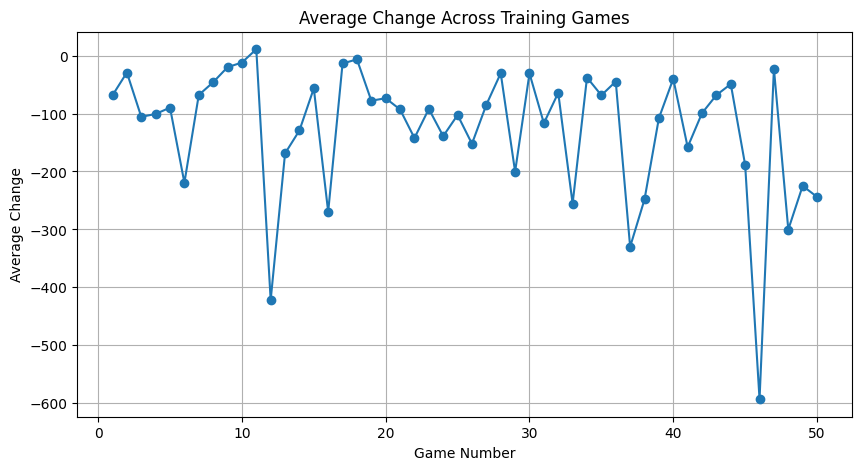

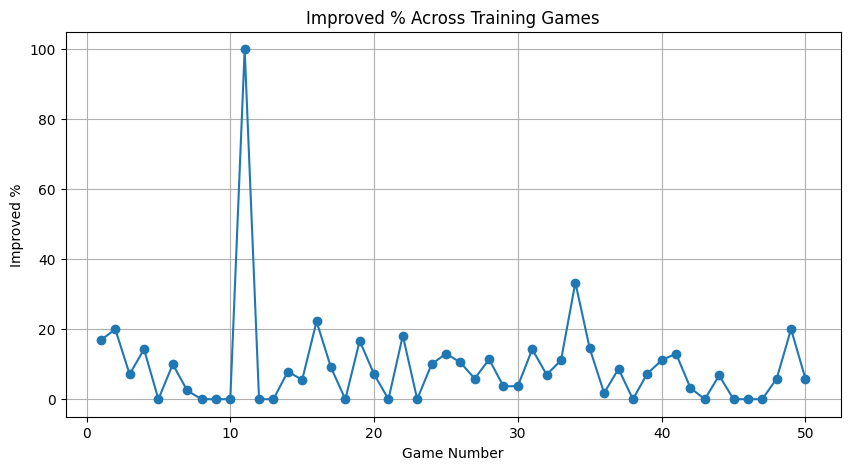

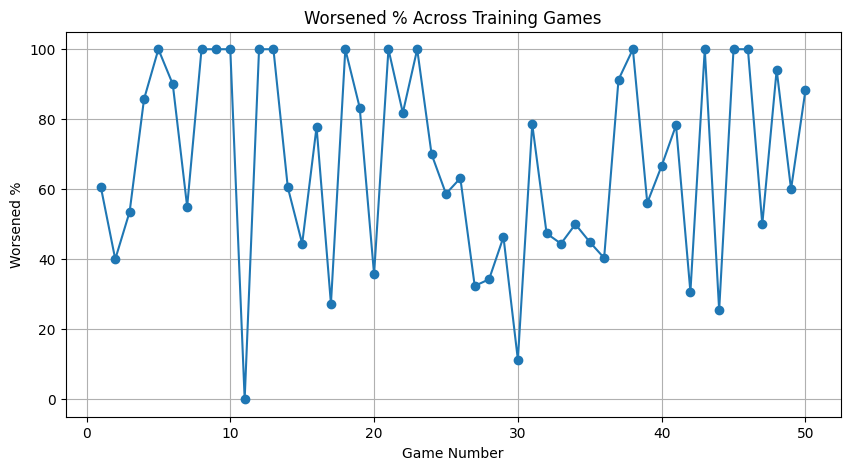

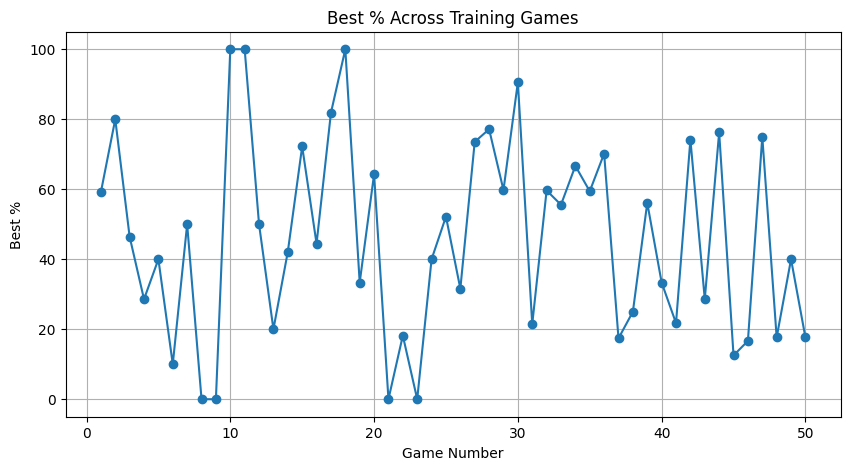

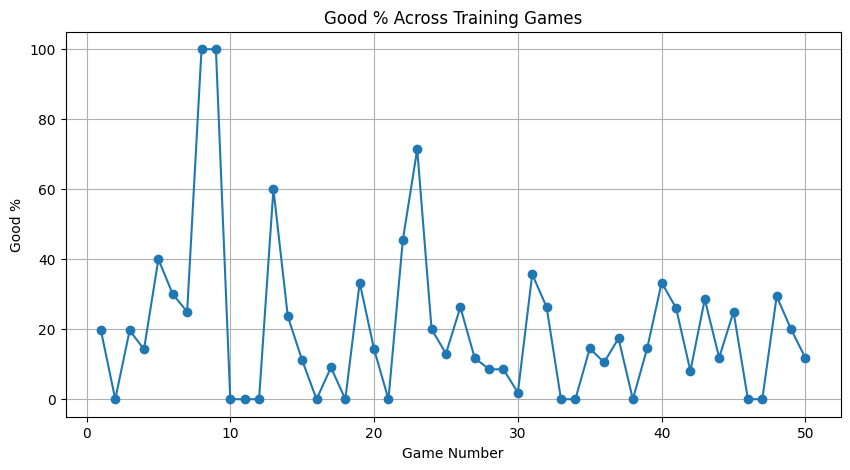

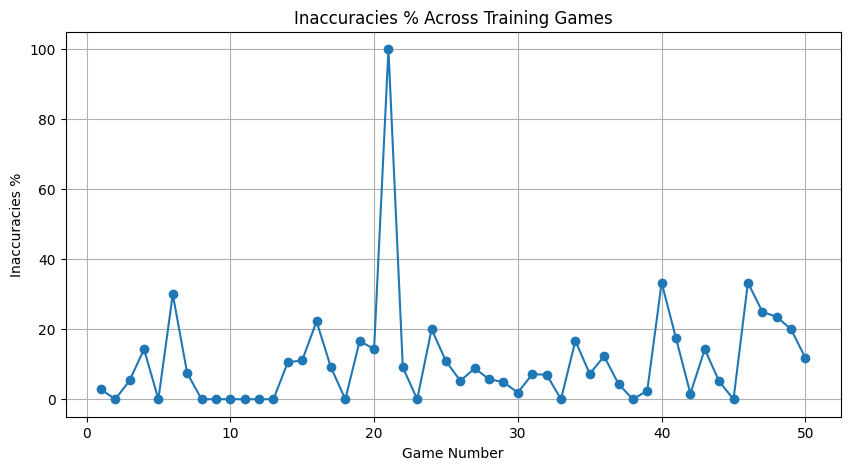

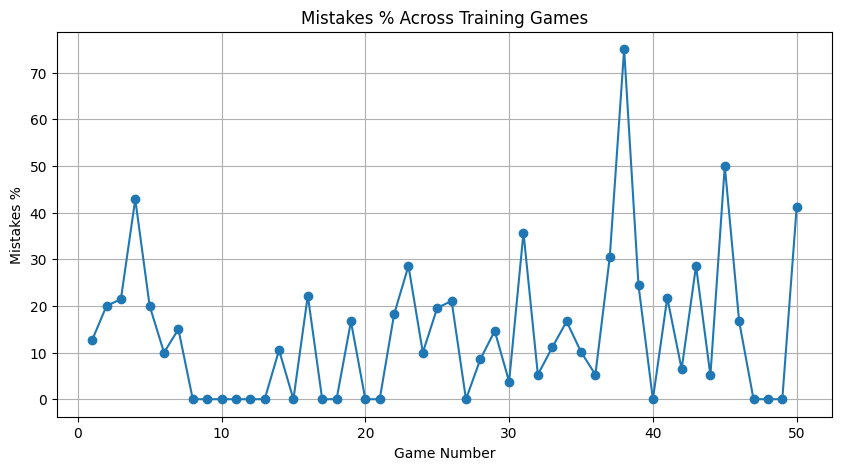

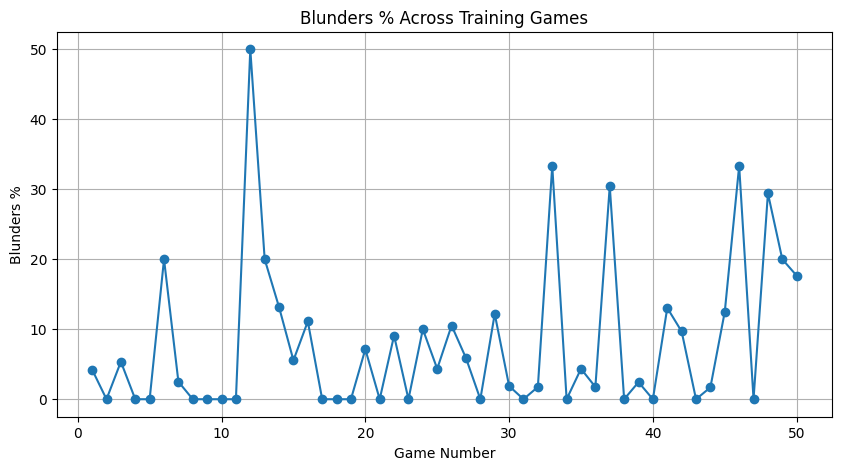

In [31]:
plot_training_trends(training_game_stats)

In [32]:
def final_report(comparison):

    print("========== FINAL GAME REPORT ==========\n")

    # ==================================================
    # OVERALL
    # ==================================================

    print("========== OVERALL ==========")

    overall = comparison["Overall"]

    for metric, result in overall.items():

        test = result["Test"]
        typical = result["Typical"]
        status = result["Status"]

        # Decide whether higher or lower is generally better
        if metric in [
            "Improved %",
            "Great %",
            "Best %"
        ]:
            if test > typical:
                remark = "↑ Higher than usual"
            elif test < typical:
                remark = "↓ Lower than usual"
            else:
                remark = "→ Around usual"

        elif metric in [
            "Worsened %",
            "Inaccuracies %",
            "Mistakes %",
            "Blunders %"
        ]:
            if test < typical:
                remark = "✓ Lower than usual"
            elif test > typical:
                remark = "⚠ Higher than usual"
            else:
                remark = "→ Around usual"

        else:
            # Average Change and Neutral %
            if status == "Above usual range":
                remark = "↑ Above usual range"
            elif status == "Below usual range":
                remark = "↓ Below usual range"
            else:
                remark = "→ Within usual range"

        if metric == "Average Change":

            print(
                f"{metric:<18} | "
                f"You: {test:.2f} | "
                f"Typical: {typical:.2f} | "
                f"{remark}"
            )

        else:

            print(
                f"{metric:<18} | "
                f"You: {test:.2f}% | "
                f"Typical: {typical:.2f}% | "
                f"{remark}"
            )


    # ==================================================
    # PHASE REPORT
    # ==================================================

    print("\n========== PHASE ANALYSIS ==========")


    for phase in ["Opening", "Middlegame", "Endgame"]:

        print(f"\n--- {phase} ---")

        phase_data = comparison[phase]

        important_points = []

        # ----------------------------------------------
        # Average Change
        # ----------------------------------------------

        if "Average Change" in phase_data:

            result = phase_data["Average Change"]

            test = result["Test"]
            typical = result["Typical"]

            if test < typical:
                important_points.append(
                    "⚠ Evaluation change was worse than usual."
                )
            elif test > typical:
                important_points.append(
                    "✓ Evaluation change was better than usual."
                )


        # ----------------------------------------------
        # Improved
        # ----------------------------------------------

        if "Improved %" in phase_data:

            result = phase_data["Improved %"]

            test = result["Test"]
            typical = result["Typical"]

            if test > typical:
                important_points.append(
                    "↑ More moves improved than usual."
                )
            elif test < typical:
                important_points.append(
                    "↓ Fewer moves improved than usual."
                )


        # ----------------------------------------------
        # Best
        # ----------------------------------------------

        if "Best %" in phase_data:

            result = phase_data["Best %"]

            test = result["Test"]
            typical = result["Typical"]

            if test < typical:
                important_points.append(
                    "⚠ Best-move rate was lower than usual."
                )
            elif test > typical:
                important_points.append(
                    "✓ Best-move rate was higher than usual."
                )


        # ----------------------------------------------
        # Great
        # ----------------------------------------------

        if "Great %" in phase_data:

            result = phase_data["Great %"]

            test = result["Test"]
            typical = result["Typical"]

            if test > typical:
                important_points.append(
                    "✓ You found more Great moves than usual."
                )
            elif test < typical and typical > 0:
                important_points.append(
                    "↓ Fewer Great moves than usual."
                )


        # ----------------------------------------------
        # Inaccuracies
        # ----------------------------------------------

        if "Inaccuracies %" in phase_data:

            result = phase_data["Inaccuracies %"]

            test = result["Test"]
            typical = result["Typical"]

            if test > typical:
                important_points.append(
                    "⚠ More inaccuracies than usual."
                )
            elif test < typical:
                important_points.append(
                    "✓ Fewer inaccuracies than usual."
                )


        # ----------------------------------------------
        # Mistakes
        # ----------------------------------------------

        if "Mistakes %" in phase_data:

            result = phase_data["Mistakes %"]

            test = result["Test"]
            typical = result["Typical"]

            if test > typical:
                important_points.append(
                    "⚠ More mistakes than usual."
                )
            elif test < typical:
                important_points.append(
                    "✓ Fewer mistakes than usual."
                )


        # ----------------------------------------------
        # Blunders
        # ----------------------------------------------

        if "Blunders %" in phase_data:

            result = phase_data["Blunders %"]

            test = result["Test"]
            typical = result["Typical"]

            if test > typical:
                important_points.append(
                    "⚠ More blunders than usual."
                )
            elif test < typical:
                important_points.append(
                    "✓ Fewer blunders than usual."
                )


        # ----------------------------------------------
        # Print only useful observations
        # ----------------------------------------------

        if important_points:

            for point in important_points:
                print(point)

        else:
            print("→ No major difference from your usual performance.")


    print("\n========== END OF REPORT ==========")

In [33]:
# ==========================================================
#              ♟ CHESS PERFORMANCE ANALYSIS ♟
#          USING ENGINE EVALUATION & STATISTICS
# ==========================================================

print("""
╔══════════════════════════════════════════════════════════╗
║                                                     ║
║        ♟ CHESS PERFORMANCE ANALYSIS ♟              ║
║             USING ENGINE EVALUATION                 ║
║                                                     ║
╚══════════════════════════════════════════════════════════╝

WELCOME!

This project analyzes chess games using Stockfish engine
evaluation and statistical analysis to understand playing
performance and compare a new game with previous games.

The notebook follows a simple flow:

    GAME INPUT
        ↓
    ENGINE ANALYSIS
        ↓
    DATA STORAGE
        ↓
    DATA ANALYSIS
        ↓
    COMPARISON
        ↓
    FINAL REPORT

Below are the functions used in the same order as they
appear throughout the notebook.
""")


# ==========================================================
# GAME INPUT
# ==========================================================

print("""
════════════════════ GAME INPUT ═══════════════════════════

1. input_games(folder_path)
   - Call: input_games("path/to/PGN/folder")
   - Loads chess games from PGN files.

2. get_game_info(games, your_name)
   - Call: get_game_info(games, "your_username")
   - Extracts basic information such as players, colors
     and game results.
""")


# ==========================================================
# ENGINE ANALYSIS
# ==========================================================

print("""
══════════════════ ENGINE ANALYSIS ════════════════════════

3. analyze_game(game, engine, your_name, depth=17)
   - Call: analyze_game(game, engine, "your_username")
   - Performs move-by-move Stockfish evaluation.

4. analyze_my_moves(game, engine, your_name, depth=17)
   - Call: analyze_my_moves(game, engine, "your_username")
   - Focuses the analysis on the moves played by you.

5. analyze_my_moves_data(game, engine, your_name, depth=17)
   - Call: analyze_my_moves_data(game, engine, "your_username")
   - Converts your analyzed moves into structured data.

6. game_stats(game, engine, your_name, depth=17)
   - Call: game_stats(game, engine, "your_username")
   - Calculates evaluation changes and move classifications.
""")


# ==========================================================
# DATA STORAGE
# ==========================================================

print("""
════════════════════ DATA STORAGE ═════════════════════════

7. game_storage_data(games, engine, your_name, depth=17)
   - Call: game_storage_data(games, engine, "your_username")
   - Analyzes multiple games and stores the resulting
     move-level data for later analysis.
""")


# ==========================================================
# DATA ANALYSIS
# ==========================================================

print("""
════════════════════ DATA ANALYSIS ════════════════════════

8. classifier(folder_path)
   - Call: classifier("/path/to/dataset")
   - Loads and separates the training and testing datasets.

9. game_level_analysis(data)
   - Call: game_level_analysis(training_df)
   - Converts move-level data into statistics for each game
     and analyzes the Opening, Middlegame and Endgame.

10. create_training_baseline(training_games)
    - Call: create_training_baseline(training_game_stats)
    - Creates a typical performance profile from the
      training games.
""")


# ==========================================================
# COMPARISON
# ==========================================================

print("""
══════════════════════ COMPARISON ═════════════════════════

11. compare_data(training_baseline, testing_game)
    - Call: compare_data(training_baseline, testing_game_stats)
    - Compares the test game with your typical performance
      across the overall game and its three phases.

12. trend_analysis(training_games)
    - Call: trend_analysis(training_game_stats)
    - Examines how your performance changes across the
      training games.
""")


# ==========================================================
# FINAL REPORT
# ==========================================================

print("""
════════════════════ FINAL REPORT ═════════════════════════

13. final_report(comparison)
    - Call: final_report(comparison)
    - Produces a compact, user-friendly report containing
      overall statistics and important observations for
      the Opening, Middlegame and Endgame.


══════════════════════════════════════════════════════════

                    ♟ PROJECT COMPLETE ♟

The complete pipeline takes raw chess games, analyzes
them with Stockfish, stores the results, establishes a
personal baseline, compares a new game against that
baseline, and produces an interpretable performance report.

══════════════════════════════════════════════════════════
""")


╔══════════════════════════════════════════════════════════╗
║                                                     ║
║        ♟ CHESS PERFORMANCE ANALYSIS ♟              ║
║             USING ENGINE EVALUATION                 ║
║                                                     ║
╚══════════════════════════════════════════════════════════╝

WELCOME!

This project analyzes chess games using Stockfish engine
evaluation and statistical analysis to understand playing
performance and compare a new game with previous games.

The notebook follows a simple flow:

    GAME INPUT
        ↓
    ENGINE ANALYSIS
        ↓
    DATA STORAGE
        ↓
    DATA ANALYSIS
        ↓
    COMPARISON
        ↓
    FINAL REPORT

Below are the functions used in the same order as they
appear throughout the notebook.


════════════════════ GAME INPUT ═══════════════════════════

1. input_games(folder_path)
   - Call: input_games("path/to/PGN/folder")
   - Loads chess games from PGN files.

2. get_game_info(g